<a href="https://www.kaggle.com/code/nithinreddy600/q13-market-research-component?scriptVersionId=322271550" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Q13 — Which Market Looks Most Sensitive to Global Events?

**Question 13:** From your analysis, which market looks most sensitive to global events: Oil, Gold, Silver or currencies?  
**Required output:** Short argument supported by chart or table.

**Dataset link used:** https://www.kaggle.com/datasets/nithinreddy600/dbs-research/data  
**Kaggle dataset slug:** `nithinreddy600/dbs-research`




In [1]:
# ============================================================
# Q13: Load Kaggle dataset properly
# Dataset: https://www.kaggle.com/datasets/nithinreddy600/dbs-research/data
# ============================================================

import os
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Hide pandas date parsing warnings from non-date columns
warnings.filterwarnings('ignore', message='Could not infer format.*', category=UserWarning)

KAGGLE_DATASET_SLUG = "nithinreddy600/dbs-research"

def resolve_dataset_root():
    """
    Finds the Kaggle dataset folder.

    On Kaggle:
    1. Open notebook
    2. Click Add Data
    3. Add dataset: nithinreddy600/dbs-research
    4. Dataset should usually appear at /kaggle/input/dbs-research
    """
    exact_paths = [
        Path("/kaggle/input/dbs-research"),
        Path("/kaggle/input/dbs-research/data"),
    ]

    for path in exact_paths:
        if path.exists():
            return path

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for path in kaggle_input.iterdir():
            if path.is_dir() and "dbs" in path.name.lower():
                return path

    # Local/Colab fallback
    try:
        import kagglehub
        downloaded_path = kagglehub.dataset_download(KAGGLE_DATASET_SLUG)
        return Path(downloaded_path)
    except Exception as e:
        raise RuntimeError(
            "Dataset folder was not found. On Kaggle, attach the dataset first: "
            "Add Data -> search 'nithinreddy600/dbs-research'."
        ) from e

DATASET_ROOT = resolve_dataset_root()
print("Dataset root:", DATASET_ROOT)

all_files = [p for p in DATASET_ROOT.rglob("*") if p.is_file()]
print("Total files found:", len(all_files))

for i, file in enumerate(all_files, start=1):
    print(f"{i:02d}. {file.relative_to(DATASET_ROOT)}")


Dataset root: /kaggle/input/datasets/nithinreddy600/dbs-research
Total files found: 5
01. Gold 100years.csv
02. Brent Oil.csv
03. silver 100 years.csv
04. swift_currency_tracker_all_reports.csv
05. global-currency-tracker-april-2026.pdf


In [2]:
# ============================================================
# Load CSV and Excel files
# ============================================================

def read_csv_safely(path):
    encodings = ["utf-8", "utf-8-sig", "latin1", "cp1252"]
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            pass
    return None

def read_excel_safely(path):
    try:
        return pd.read_excel(path, sheet_name=None)
    except Exception:
        return None

loaded_tables = []

for file in all_files:
    suffix = file.suffix.lower()

    if suffix == ".csv":
        df = read_csv_safely(file)
        if df is not None and not df.empty:
            loaded_tables.append({"file": file, "sheet": None, "df": df})

    elif suffix in [".xlsx", ".xls"]:
        sheets = read_excel_safely(file)
        if sheets:
            for sheet_name, df in sheets.items():
                if df is not None and not df.empty:
                    loaded_tables.append({"file": file, "sheet": sheet_name, "df": df})

print("Tables loaded:", len(loaded_tables))
for item in loaded_tables:
    print("TABLE:", item["file"].relative_to(DATASET_ROOT), "| sheet:", item["sheet"], "| shape:", item["df"].shape)


Tables loaded: 4
TABLE: Gold 100years.csv | sheet: None | shape: (1336, 3)
TABLE: Brent Oil.csv | sheet: None | shape: (963, 3)
TABLE: silver 100 years.csv | sheet: None | shape: (1336, 3)
TABLE: swift_currency_tracker_all_reports.csv | sheet: None | shape: (288, 9)


In [3]:
# ============================================================
# Helper functions for date/value extraction
# ============================================================

def normalize_col(c):
    return re.sub(r"\s+", " ", str(c).replace("\xa0", " ")).strip()

def clean_numeric_series(s):
    """
    Converts values such as '$1,234.50', '1,234.50', '12.5%' to numeric.
    """
    return pd.to_numeric(
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.replace("$", "", regex=False)
         .str.replace("%", "", regex=False)
         .str.replace("−", "-", regex=False)
         .str.strip(),
        errors="coerce"
    )

def looks_like_date_column(series, col_name):
    """
    Checks whether a column is likely to contain dates before using pd.to_datetime.
    This prevents repeated pandas warnings from non-date text columns.
    """
    col_lower = str(col_name).lower()

    # Column name is a strong signal
    name_has_date_word = any(word in col_lower for word in ["date", "month", "year", "time"])

    # Sample values
    sample = series.dropna().astype(str).head(20)
    if sample.empty:
        return False

    sample_text = " ".join(sample.tolist())

    # Common date patterns: 2026-01-01, 01/01/2026, Jan 2026, January 2026
    date_pattern = (
        r"\d{4}[-/]\d{1,2}[-/]\d{1,2}|"
        r"\d{1,2}[-/]\d{1,2}[-/]\d{2,4}|"
        r"(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)[a-z]*\s+\d{4}|"
        r"\d{4}"
    )

    sample_has_date_pattern = re.search(date_pattern, sample_text, flags=re.IGNORECASE) is not None

    return name_has_date_word or sample_has_date_pattern


def find_date_column(df):
    """
    Finds the best date column without printing pandas date-parsing warnings.
    """
    date_candidates = []

    for col in df.columns:
        if not looks_like_date_column(df[col], col):
            continue

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            parsed = pd.to_datetime(df[col], errors="coerce", dayfirst=False)

        valid = parsed.notna().sum()

        score = valid
        col_lower = str(col).lower()
        if any(word in col_lower for word in ["date", "month", "year", "time"]):
            score += 50

        if valid >= max(3, int(len(df) * 0.20)):
            date_candidates.append((score, col, parsed))

    if not date_candidates:
        return None, None

    date_candidates.sort(key=lambda x: x[0], reverse=True)
    return date_candidates[0][1], date_candidates[0][2]


def find_value_column(df, date_col=None):
    """
    Finds the most likely price/value/share column.
    """
    candidates = []

    preferred_words = [
        "price", "value", "close", "last", "average", "avg",
        "brent", "gold", "silver", "share", "weight", "usd", "rate"
    ]

    for col in df.columns:
        if col == date_col:
            continue

        numeric = clean_numeric_series(df[col])
        valid = numeric.notna().sum()

        if valid < max(3, int(len(df) * 0.20)):
            continue

        col_lower = str(col).lower()
        score = valid
        if any(word in col_lower for word in preferred_words):
            score += 50

        # Avoid rank columns as price/share columns.
        if "rank" in col_lower:
            score -= 100

        candidates.append((score, col, numeric))

    if not candidates:
        return None, None

    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][1], candidates[0][2]

def extract_timeseries_from_table(item):
    """
    Extracts a clean Date-Value dataframe from a loaded table.
    """
    df = item["df"].copy()
    df.columns = [normalize_col(c) for c in df.columns]

    date_col, parsed_dates = find_date_column(df)
    if date_col is None:
        return None

    value_col, values = find_value_column(df, date_col=date_col)
    if value_col is None:
        return None

    ts = pd.DataFrame({
        "Date": parsed_dates,
        "Value": values
    }).dropna()

    ts = ts.sort_values("Date").drop_duplicates(subset=["Date"], keep="last")
    if len(ts) < 3:
        return None

    return ts, date_col, value_col

def filename_text(item):
    sheet = item["sheet"] or ""
    return f"{item['file'].name} {sheet}".lower()

def table_preview_text(item):
    df = item["df"]
    text = " ".join(map(str, df.columns)) + " " + df.head(20).astype(str).to_string()
    return text.lower()

def choose_market_table(market_name, keywords, exclude_keywords=None):
    """
    Finds the most likely table for a market by filename and column/sample text.
    """
    exclude_keywords = exclude_keywords or []
    candidates = []

    for item in loaded_tables:
        name_text = filename_text(item)
        preview = table_preview_text(item)
        combined = name_text + " " + preview

        if any(ex in combined for ex in exclude_keywords):
            continue

        score = sum(20 for kw in keywords if kw.lower() in name_text)
        score += sum(5 for kw in keywords if kw.lower() in preview)

        extracted = extract_timeseries_from_table(item)
        if extracted is None:
            continue

        if score > 0:
            candidates.append((score, item, extracted))

    if not candidates:
        raise ValueError(f"Could not find a suitable dataset for {market_name}. Check file names and columns.")

    candidates.sort(key=lambda x: x[0], reverse=True)
    score, item, extracted = candidates[0]
    ts, date_col, value_col = extracted

    print(f"{market_name} selected file:", item["file"].relative_to(DATASET_ROOT))
    print(f"{market_name} date column:", date_col, "| value column:", value_col)
    print(f"{market_name} source period:", ts["Date"].min().date(), "to", ts["Date"].max().date())

    return {
        "Market": market_name,
        "Source File": item["file"].name,
        "Date Column": date_col,
        "Value Column": value_col,
        "Data": ts
    }


In [4]:
# ============================================================
# Extract Oil, Gold and Silver time series
# ============================================================

oil = choose_market_table(
    "Oil",
    keywords=["brent", "oil"],
    exclude_keywords=["gold", "silver", "swift"]
)

gold = choose_market_table(
    "Gold",
    keywords=["gold"],
    exclude_keywords=["silver", "brent", "oil", "swift"]
)

silver = choose_market_table(
    "Silver",
    keywords=["silver"],
    exclude_keywords=["gold", "brent", "oil", "swift"]
)

commodity_series = [oil, gold, silver]


Oil selected file: Brent Oil.csv
Oil date column: date_str | value column: Value
Oil source period: 1946-01-01 to 2026-03-01
Gold selected file: Gold 100years.csv
Gold date column: date_str | value column: Value
Gold source period: 1915-01-01 to 2026-04-01
Silver selected file: silver 100 years.csv
Silver date column: date_str | value column: Value
Silver source period: 1915-01-01 to 2026-04-01


In [5]:
# ============================================================
# Extract currency data from SWIFT/global currency tracker
# ============================================================

CURRENCY_CODES = ["USD", "EUR", "GBP", "JPY", "CNY", "RMB"]

def extract_currency_timeseries_from_item(item):
    """
    Supports two currency data shapes:

    1. Wide table:
       Date | USD | EUR | GBP | JPY | CNY

    2. Long table:
       Date | Currency | Share
       Date | Code     | Value
    """
    df = item["df"].copy()
    df.columns = [normalize_col(c) for c in df.columns]

    date_col, parsed_dates = find_date_column(df)
    if date_col is None:
        return None

    # -------- Wide format --------
    currency_cols = []
    for col in df.columns:
        col_upper = str(col).upper()
        if col == date_col:
            continue
        if any(code in col_upper for code in CURRENCY_CODES):
            numeric = clean_numeric_series(df[col])
            if numeric.notna().sum() >= 3:
                currency_cols.append(col)

    if currency_cols:
        wide = pd.DataFrame({"Date": parsed_dates})
        for col in currency_cols:
            wide[col] = clean_numeric_series(df[col])
        wide = wide.dropna(subset=["Date"]).sort_values("Date")
        wide = wide.drop_duplicates(subset=["Date"], keep="last")
        value_cols = [c for c in wide.columns if c != "Date"]
        wide["Currency Composite"] = wide[value_cols].mean(axis=1, skipna=True)
        ts = wide[["Date", "Currency Composite"]].rename(columns={"Currency Composite": "Value"}).dropna()
        return ts, date_col, ", ".join(currency_cols)

    # -------- Long format --------
    currency_col_candidates = []
    for col in df.columns:
        if col == date_col:
            continue
        text = df[col].astype(str).str.upper()
        hits = sum(text.str.contains(code, na=False).sum() for code in CURRENCY_CODES)
        if hits >= 3:
            currency_col_candidates.append((hits, col))

    if currency_col_candidates:
        currency_col_candidates.sort(reverse=True)
        currency_col = currency_col_candidates[0][1]

        share_col = None
        share_numeric = None
        for col in df.columns:
            if col in [date_col, currency_col]:
                continue
            numeric = clean_numeric_series(df[col])
            if numeric.notna().sum() >= 3:
                name_score = 10 if any(w in str(col).lower() for w in ["share", "payment", "value", "weight", "%"]) else 0
                candidate_score = numeric.notna().sum() + name_score
                if share_col is None or candidate_score > best_score:
                    share_col = col
                    share_numeric = numeric
                    best_score = candidate_score

        if share_col is not None:
            long_df = pd.DataFrame({
                "Date": parsed_dates,
                "Currency": df[currency_col].astype(str).str.upper(),
                "Share": share_numeric
            }).dropna()

            long_df = long_df[long_df["Currency"].apply(lambda x: any(code in x for code in CURRENCY_CODES))]
            if len(long_df) >= 3:
                pivot = long_df.pivot_table(index="Date", columns="Currency", values="Share", aggfunc="mean").sort_index()
                pivot["Currency Composite"] = pivot.mean(axis=1, skipna=True)
                ts = pivot.reset_index()[["Date", "Currency Composite"]].rename(columns={"Currency Composite": "Value"}).dropna()
                return ts, date_col, f"{currency_col} + {share_col}"

    return None

def choose_currency_table():
    candidates = []

    for item in loaded_tables:
        combined = filename_text(item) + " " + table_preview_text(item)
        if not any(word in combined for word in ["swift", "currency", "payment", "cny", "rmb", "usd"]):
            continue

        extracted = extract_currency_timeseries_from_item(item)
        if extracted is None:
            continue

        score = 0
        for word in ["swift", "currency", "tracker", "payment", "usd", "cny", "rmb"]:
            if word in combined:
                score += 10

        candidates.append((score, item, extracted))

    if not candidates:
        raise ValueError(
            "Could not find currency time-series data. Check whether the dataset contains "
            "swift_currency_tracker_all_reports.csv or another currency tracker file."
        )

    candidates.sort(key=lambda x: x[0], reverse=True)
    score, item, extracted = candidates[0]
    ts, date_col, value_col = extracted

    print("Currencies selected file:", item["file"].relative_to(DATASET_ROOT))
    print("Currencies date column:", date_col, "| value columns used:", value_col)
    print("Currencies source period:", ts["Date"].min().date(), "to", ts["Date"].max().date())

    return {
        "Market": "Currencies",
        "Source File": item["file"].name,
        "Date Column": date_col,
        "Value Column": value_col,
        "Data": ts
    }

currencies = choose_currency_table()
all_market_series = commodity_series + [currencies]


Currencies selected file: swift_currency_tracker_all_reports.csv
Currencies date column: report_month | value columns used: metric + value
Currencies source period: 2026-01-01 to 2026-04-01


In [6]:
# ============================================================
# Convert each market to monthly data and calculate fair analysis period
# ============================================================

def to_monthly_series(ts):
    """
    Resamples each market to monthly frequency.
    Monthly mean is used because commodity files may be daily, weekly or monthly.
    """
    x = ts.copy()
    x = x.dropna(subset=["Date", "Value"]).sort_values("Date")
    x = x.set_index("Date")["Value"].astype(float)
    monthly = x.resample("MS").mean().dropna()
    return monthly

monthly_series = {}
source_periods = {}

for item in all_market_series:
    market = item["Market"]
    monthly = to_monthly_series(item["Data"])
    monthly_series[market] = monthly
    source_periods[market] = {
        "Source Start": item["Data"]["Date"].min(),
        "Source End": item["Data"]["Date"].max(),
        "Source File": item["Source File"]
    }

    print(market, "| monthly rows:", len(monthly), "| monthly period:", monthly.index.min().date(), "to", monthly.index.max().date())

# Use common overlapping period so markets are compared fairly.
common_start = max(series.index.min() for series in monthly_series.values())
common_end = min(series.index.max() for series in monthly_series.values())


def month_year(date_value):
    """Converts a date to Month Year format, for example January 2026."""
    return pd.to_datetime(date_value).strftime("%B %Y")

analysis_start_month = month_year(common_start)
analysis_end_month = month_year(common_end)
analysis_period_month_text = f"{analysis_start_month} to {analysis_end_month}"

print("\nCommon analysis period:", common_start.date(), "to", common_end.date())
print("Common analysis period with month names:", analysis_period_month_text)


monthly_common = {}
for market, series in monthly_series.items():
    filtered = series.loc[(series.index >= common_start) & (series.index <= common_end)].dropna()
    monthly_common[market] = filtered

if min(len(s) for s in monthly_common.values()) < 6:
    print(
        "Warning: common overlap has fewer than 6 monthly observations for at least one market. "
        "The notebook will continue, but check your dataset coverage."
    )


Oil | monthly rows: 963 | monthly period: 1946-01-01 to 2026-03-01
Gold | monthly rows: 1336 | monthly period: 1915-01-01 to 2026-04-01
Silver | monthly rows: 1336 | monthly period: 1915-01-01 to 2026-04-01
Currencies | monthly rows: 4 | monthly period: 2026-01-01 to 2026-04-01

Common analysis period: 2026-01-01 to 2026-03-01
Common analysis period with month names: January 2026 to March 2026


In [7]:
# ============================================================
# Sensitivity calculation
# ============================================================
# Method:
# - Convert each market to monthly percentage changes.
# - Calculate:
#   1. Volatility = standard deviation of monthly % changes
#   2. Average absolute monthly change
#   3. Maximum absolute monthly change
# - Sensitivity Score = 0.60 * Volatility + 0.40 * Maximum Absolute Monthly Change
#
# A higher score means the market moved more strongly during the analysis period.

summary_rows = []
returns_dict = {}
index_dict = {}

for item in all_market_series:
    market = item["Market"]
    values = monthly_common[market].copy()

    # Normalized index for chart: first value = 100.
    index_series = (values / values.iloc[0]) * 100
    index_dict[market] = index_series

    returns = values.pct_change().dropna() * 100
    returns_dict[market] = returns

    source_start = source_periods[market]["Source Start"]
    source_end = source_periods[market]["Source End"]

    volatility = returns.std()
    avg_abs_change = returns.abs().mean()
    max_abs_change = returns.abs().max()
    sensitivity_score = (0.60 * volatility) + (0.40 * max_abs_change)

    summary_rows.append({
        "Market": market,
        "Source File": source_periods[market]["Source File"],
        "Source Start Date": source_start.date(),
        "Source End Date": source_end.date(),
        "Analysis Start Date": common_start.date(),
        "Analysis End Date": common_end.date(),
        "Analysis Start Month": analysis_start_month,
        "Analysis End Month": analysis_end_month,
        "Analysis Period Used": analysis_period_month_text,
        "Monthly Observations Used": len(values),
        "Monthly Return Volatility (%)": round(volatility, 3),
        "Average Absolute Monthly Change (%)": round(avg_abs_change, 3),
        "Maximum Absolute Monthly Change (%)": round(max_abs_change, 3),
        "Sensitivity Score": round(sensitivity_score, 3)
    })

sensitivity_table = pd.DataFrame(summary_rows)
sensitivity_table = sensitivity_table.sort_values("Sensitivity Score", ascending=False).reset_index(drop=True)
sensitivity_table.insert(0, "Rank", range(1, len(sensitivity_table) + 1))

sensitivity_table.to_csv("Q13_market_sensitivity_summary_table.csv", index=False)
display(sensitivity_table)


,Rank,Market,Source File,Source Start Date,Source End Date,Analysis Start Date,Analysis End Date,Analysis Start Month,Analysis End Month,Analysis Period Used,Monthly Observations Used,Monthly Return Volatility (%),Average Absolute Monthly Change (%),Maximum Absolute Monthly Change (%),Sensitivity Score
0,1,Oil,Brent Oil.csv,1946-01-01,2026-03-01,2026-01-01,2026-03-01,January 2026,March 2026,January 2026 to March 2026,3,34.433,27.677,52.025,41.470
1,2,Gold,Gold 100years.csv,1915-01-01,2026-04-01,2026-01-01,2026-03-01,January 2026,March 2026,January 2026 to March 2026,3,14.135,9.995,11.511,13.086
2,3,Silver,silver 100 years.csv,1915-01-01,2026-04-01,2026-01-01,2026-03-01,January 2026,March 2026,January 2026 to March 2026,3,8.591,11.733,17.808,12.278
3,4,Currencies,swift_currency_tracker_all_reports.csv,2026-01-01,2026-04-01,2026-01-01,2026-03-01,January 2026,March 2026,January 2026 to March 2026,3,1.614,4.069,5.211,3.053


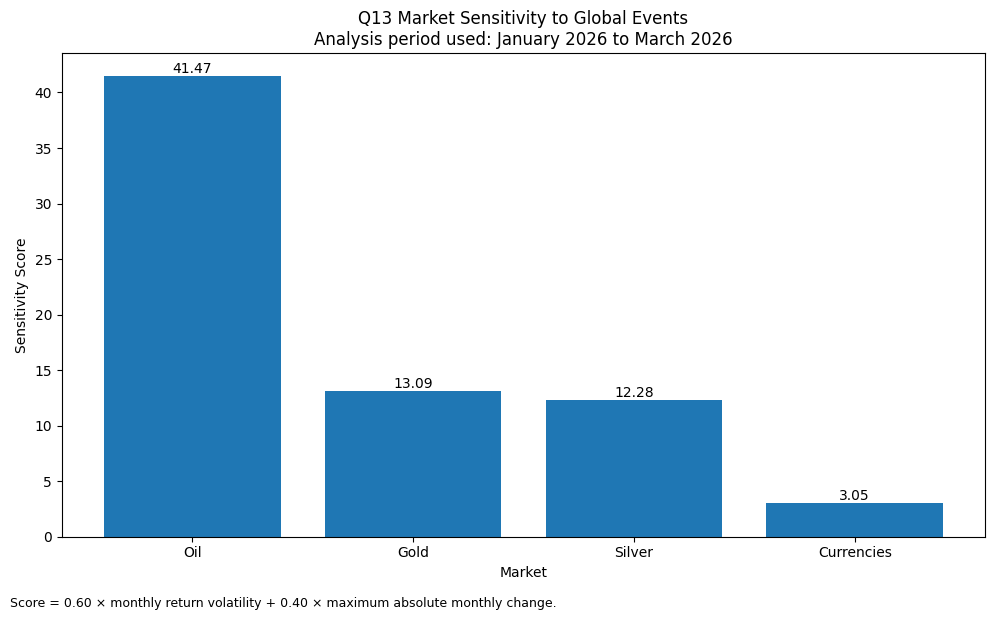

In [8]:
# ============================================================
# Chart 1: Sensitivity score by market
# The chart title clearly states from when the data is analysed.
# ============================================================

analysis_period_text = analysis_period_month_text

plt.figure(figsize=(10, 6))
plt.bar(sensitivity_table["Market"], sensitivity_table["Sensitivity Score"])

plt.title(f"Q13 Market Sensitivity to Global Events\nAnalysis period used: {analysis_period_text}")
plt.xlabel("Market")
plt.ylabel("Sensitivity Score")

for i, value in enumerate(sensitivity_table["Sensitivity Score"]):
    plt.text(i, value, f"{value:.2f}", ha="center", va="bottom")

plt.figtext(
    0.01, -0.02,
    "Score = 0.60 × monthly return volatility + 0.40 × maximum absolute monthly change.",
    ha="left",
    fontsize=9
)

plt.tight_layout()
plt.savefig("Q13_market_sensitivity_score_chart.png", dpi=200, bbox_inches="tight")
plt.show()


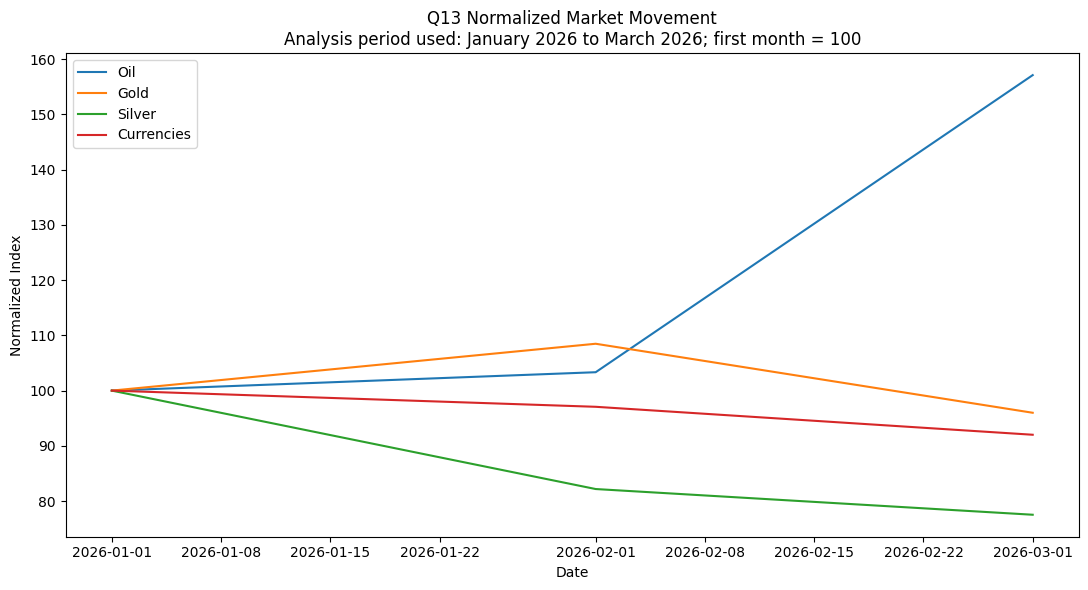

,Oil,Gold,Silver,Currencies
Date,,,,
2026-01-01,100.000000,100.000000,100.000000,100.000000
2026-02-01,103.329261,108.479143,82.191925,97.072330
2026-03-01,157.086133,95.992038,77.540877,92.014207


In [9]:
# ============================================================
# Chart 2: Normalized market movement
# This helps visually support which market moved more strongly.
# ============================================================

normalized_df = pd.DataFrame(index_dict)
normalized_df.index.name = "Date"
normalized_df.to_csv("Q13_normalized_market_index_table.csv")

plt.figure(figsize=(11, 6))

for market in normalized_df.columns:
    plt.plot(normalized_df.index, normalized_df[market], label=market)

plt.title(f"Q13 Normalized Market Movement\nAnalysis period used: {analysis_period_text}; first month = 100")
plt.xlabel("Date")
plt.ylabel("Normalized Index")
plt.legend()
plt.tight_layout()
plt.savefig("Q13_normalized_market_movement_chart.png", dpi=200, bbox_inches="tight")
plt.show()

display(normalized_df.head())


In [10]:
# ============================================================
# Final short answer for Q13
# ============================================================

top = sensitivity_table.iloc[0]
second = sensitivity_table.iloc[1]

answer = (
    f"Based on the analysis from {top['Analysis Period Used']}, "
    f"{top['Market']} looks like the most sensitive market to global events. "
    f"It ranks 1st with a sensitivity score of {top['Sensitivity Score']}, "
    f"monthly return volatility of {top['Monthly Return Volatility (%)']}%, and a maximum absolute monthly change of "
    f"{top['Maximum Absolute Monthly Change (%)']}%. "
    f"This is higher than {second['Market']}, which ranks 2nd with a score of {second['Sensitivity Score']}. "
    f"The result suggests that {top['Market']} reacted more strongly to global shocks during the common analysis period "
    f"({top['Analysis Period Used']}), as shown in the sensitivity summary table and the market sensitivity score chart."
)

print(answer)

with open("Q13_final_answer.txt", "w", encoding="utf-8") as f:
    f.write(answer)


Based on the analysis from January 2026 to March 2026, Oil looks like the most sensitive market to global events. It ranks 1st with a sensitivity score of 41.47, monthly return volatility of 34.433%, and a maximum absolute monthly change of 52.025%. This is higher than Gold, which ranks 2nd with a score of 13.086. The result suggests that Oil reacted more strongly to global shocks during the common analysis period (January 2026 to March 2026), as shown in the sensitivity summary table and the market sensitivity score chart.
